In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
import seaborn as sns
import bayesflow as bf

import sys
sys.path.append("../")

from src.generative_models import *
from src.priors import pt_prior, mvl_prior

np.set_printoptions(suppress=True)

/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
NUM_SIM = 200
NUM_SAMPLES = 1000

AGENT_LABELS = [
    "Loss averse", "Var averse", "Both aversions", "No aversions",
]
DATA_TYPE = ["New Lotteries", "Old Lotteries"]

FONTSIZE_1 = 20
FONTSIZE_2 = 16
FONTSIZE_3 = 14

In [3]:
import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

## Context

In [4]:
gamble_new = pd.read_csv('../data/three_outcome_lotteries_new.csv')
# gamble_new = gamble_new.loc[gamble_new.ev_diff == 0]
gamble_old = pd.read_csv('../data/three_outcome_lotteries_traditional.csv')
# gamble_old = gamble_old.loc[gamble_old.ev_diff == 0]

context_new = gamble_new[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

context_old = gamble_old[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

## Agents

In [5]:
pt_tau = 5
mvl_tau = 1.5
b_weights = 0.5
alpha = 0.7
lamda = 2

theta_pt_la = np.array([lamda, 1, pt_tau])
theta_pt_var = np.array([1, alpha, pt_tau])
theta_pt_both = np.array([1.7, alpha, pt_tau])
theta_pt_no = np.array([1, 1, pt_tau])

theta_pt = [theta_pt_la, theta_pt_var, theta_pt_both, theta_pt_no]

theta_mvl_la = np.array([0, b_weights, mvl_tau])
theta_mvl_var = np.array([b_weights, 0, mvl_tau])
theta_mvl_both = np.array([b_weights, 0.3, mvl_tau])
theta_mvl_no = np.array([0, 0, mvl_tau])

theta_mvl = [theta_mvl_la, theta_mvl_var, theta_mvl_both, theta_mvl_no]

## Data Simulation

In [6]:
pt_agent_data = np.zeros((2, 4, NUM_SIM, context_new.shape[0], 7))
mvl_agent_data = np.zeros((2, 4, NUM_SIM, context_new.shape[0], 7))

In [7]:
trans_context_new = context_new / 50
trans_context_old = context_old / 50
for i in range(NUM_SIM):
    for j in range(4):
        pt_agent_data[0, j, i, :, 0] = sample_pt_model(theta_pt[j], context_new)
        pt_agent_data[0, j, i, :, 1:] = trans_context_new
        pt_agent_data[1, j, i, :, 0] = sample_pt_model(theta_pt[j], context_old)
        pt_agent_data[1, j, i, :, 1:] = trans_context_old
        mvl_agent_data[0, j, i, :, 0] = sample_mvl_model(theta_mvl[j], context_new)
        mvl_agent_data[0, j, i, :, 1:] = trans_context_new
        mvl_agent_data[1, j, i, :, 0] = sample_mvl_model(theta_mvl[j], context_old)
        mvl_agent_data[1, j, i, :, 1:] = trans_context_old

In [8]:
pt_agent_data_means = pt_agent_data[:, :, :, :, 0].mean(axis=3).mean(axis=2)
mvl_agent_data_means = mvl_agent_data[:, :, :, :, 0].mean(axis=3).mean(axis=2)
pt_agent_data_stds = pt_agent_data[:, :, :, :, 0].mean(axis=3).std(axis=2)
mvl_agent_data_stds = mvl_agent_data[:, :, :, :, 0].mean(axis=3).std(axis=2)

means = [pt_agent_data_means, mvl_agent_data_means]
stds = [pt_agent_data_stds, mvl_agent_data_stds]

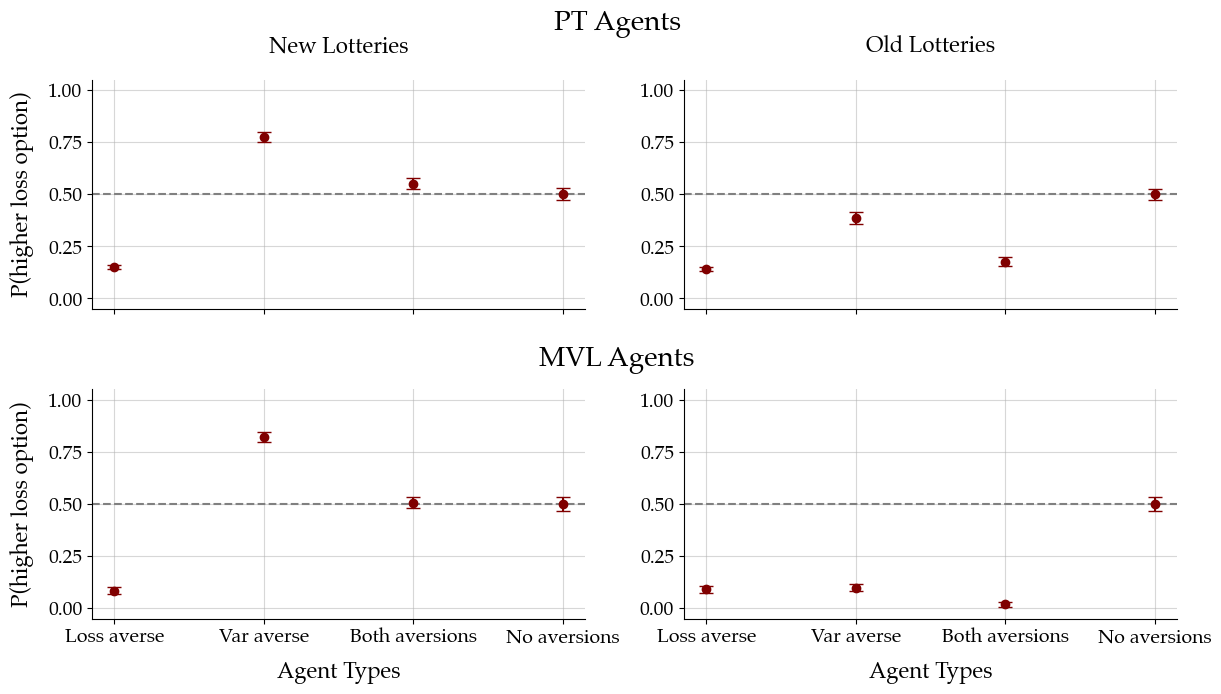

In [9]:
fig, axrr = plt.subplots(2, 2, figsize=(14, 7))
fig.text(0.5, 0.96, 'PT Agents', ha='center', va='center', fontsize=FONTSIZE_1)
fig.text(0.5, 0.48, 'MVL Agents', ha='center', va='center', fontsize=FONTSIZE_1)

for i, ax in enumerate(axrr.flat):
    if i < 2:
        for j in range(4):
            ax.errorbar(
                AGENT_LABELS[j], 1 - means[0][i, j],
                yerr=stds[0][i, j], fmt='o', capsize=5,
                color='maroon', ecolor='maroon'
            )
        ax.set_xticklabels([])
        ax.set_title(DATA_TYPE[i], fontsize=FONTSIZE_2, pad=20)
    if i >= 2:
        for j in range(4):
            ax.errorbar(
                AGENT_LABELS[j], 1 - means[1][i - 2, j],
                yerr=stds[1][i - 2, j], fmt='o', capsize=5,
                color='maroon', ecolor='maroon'
            )
        ax.set_xlabel("Agent Types", fontsize=FONTSIZE_2, labelpad=10)
    if i == 0 or i == 2:
        ax.set_ylabel("P(higher loss option)", fontsize=FONTSIZE_2, labelpad=10)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=0.5, linestyle='--', color='gray', linewidth=1.5)
    ax.grid(alpha=0.5)

sns.despine()
plt.subplots_adjust(hspace=0.35)
plt.savefig("../plots/agent_simulation_summary.pdf", dpi=300, bbox_inches="tight")

## Data Fitting

In [40]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(pt_prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [41]:
pt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)
mvl_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

In [42]:
pt_trainer = bf.trainers.Trainer(
    generative_model=pt_model, 
    amortizer=pt_amortizer, 
    configurator=pt_configurator, 
    checkpoint_path=f"../checkpoints/pt_model_final",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/pt_model_final/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/pt_model_final/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [43]:
mvl_trainer = bf.trainers.Trainer(
    generative_model=mvl_model, 
    amortizer=mvl_amortizer, 
    configurator=mvl_configurator, 
    checkpoint_path=f"../checkpoints/{mvl_model.name}_2",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/mvl_model_2/history_8.pkl.
INFO:root:Networks loaded from ../checkpoints/mvl_model_2/ckpt-8
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [44]:
pt_post_z = np.zeros((2, 4, NUM_SIM, NUM_SAMPLES, 3))
mvl_post_z = np.zeros((2, 4, NUM_SIM, NUM_SAMPLES, 3))

In [59]:
for idx in np.ndindex(pt_post_z.shape[:2]):
    i, j = idx
    pt_post_z[i, j] = pt_amortizer.sample(
        {"summary_conditions": pt_agent_data[i, j].astype(np.float32)},
        NUM_SAMPLES
    )
    mvl_post_z[i, j] = mvl_amortizer.sample(
        {"summary_conditions": mvl_agent_data[i, j].astype(np.float32)},
        NUM_SAMPLES
    )

In [60]:
pt_post = pt_post_z * PT_PRIOR_STD + PT_PRIOR_MEAN
mvl_post = mvl_post_z * PT_PRIOR_STD + PT_PRIOR_MEAN

In [61]:
pt_post_median = np.median(pt_post, axis=3)
mvl_post_median = np.median(pt_post, axis=3)

In [48]:
def get_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mse = np.mean((y_true - y_pred) ** 2, axis=0)
    rmse = np.sqrt(mse)
    return rmse

In [49]:
pt_rmses = np.zeros((2, 4, 3))
mvl_rmses = np.zeros((2, 4, 3))
for idx in np.ndindex(pt_post_median.shape[:2]):
    i, j = idx
    pt_rmses[i, j] = get_rmse(theta_pt[j], pt_post_median[i, j])
    mvl_rmses[i, j] = get_rmse(theta_mvl[j], mvl_post_median[i, j])

In [52]:
pt_rmses.shape

(2, 4, 3)

In [53]:
pt_post_median.shape

(2, 4, 200, 3)

In [55]:
theta_pt

[array([2, 1, 5]),
 array([1. , 0.7, 5. ]),
 array([1.7, 0.7, 5. ]),
 array([1, 1, 5])]

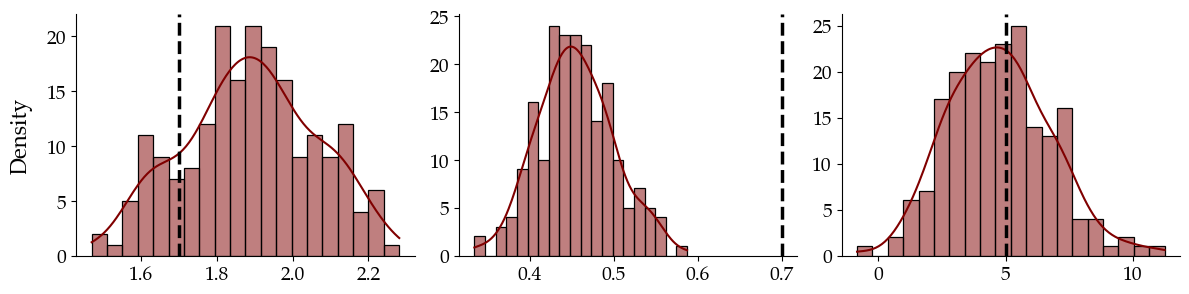

In [50]:
fig = plt.figure(figsize=(12, 3))
axs = fig.subplots(nrows=1, ncols=3)
for i, ax in enumerate(axs):
    sns.histplot(pt_post_median[0, 2, :, i], ax=ax, color='maroon', kde=True, bins=20)
    ax.axvline(x=theta_pt[2][i], linestyle='--', color='black', linewidth=2.5)
    # ax.set_title(param_names[i], fontsize=FONTSIZE_1)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    if i == 0:
        ax.set_ylabel("Density", fontsize=FONTSIZE_2, labelpad=10)
    else:
        ax.set_ylabel("")
sns.despine()
plt.tight_layout()

In [32]:
test_data = np.zeros((120, 7))
test_data[:, 0] = sample_pt_model(theta_pt[j], context_new)
test_data[:, 1:] = trans_context_new

In [33]:
theta_pt_la

array([2, 1, 5])

In [35]:
post = pt_amortizer.sample(
        {"summary_conditions": test_data[None, :, :].astype(np.float32)},
        NUM_SAMPLES
    )

In [36]:
post.shape

(1000, 3)

In [37]:
post = post * PT_PRIOR_STD + PT_PRIOR_MEAN
post_median = np.median(post, axis=0)

In [64]:
np.array(theta_pt)

array([[2. , 1. , 5. ],
       [1. , 0.7, 5. ],
       [1.7, 0.7, 5. ],
       [1. , 1. , 5. ]])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data
true_params = np.array(theta_pt)

# Prepare data for plotting
data = []
param_names = [r'$\lambda$', r'$\alpha$', r'$\tau$']
panels = ['New lotteries', 'Old lotteries']

for i in range(2):  # Loop over panels
    for j in range(3):  # Loop over parameters
        for k in range(4):  # Loop over scenarios
            for l in range(200):  # Loop over repetitions
                data.append([panels[i], f'Scenario {k+1}:{param_names[j]}', pt_post_median[i, k, l, j]])

data = np.array(data)
df = pd.DataFrame(data, columns=['Panel', 'Parameter_Scenario', 'Value'])
df['Value'] = df['Value'].astype(float)


In [66]:
df

,Panel,Parameter_Scenario,Value
0,Panel 1,Scenario 1:$\lambda$,1.321003
1,Panel 1,Scenario 1:$\lambda$,1.476636
2,Panel 1,Scenario 1:$\lambda$,1.289141
3,Panel 1,Scenario 1:$\lambda$,1.512268
4,Panel 1,Scenario 1:$\lambda$,1.542215
...,...,...,...
4795,Panel 2,Scenario 4:$\tau$,20.511557
4796,Panel 2,Scenario 4:$\tau$,21.891575
4797,Panel 2,Scenario 4:$\tau$,21.901673
4798,Panel 2,Scenario 4:$\tau$,21.416471


In [ ]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i, panel in enumerate(panels):  # Loop over panels
    ax = axes[i]
    sns.violinplot(x='Parameter_Scenario', y='Value', data=df[df['Panel'] == panel], ax=ax)
    for j in range(3):  # Loop over parameters
        for k in range(4):  # Loop over scenarios
            ax.axhline(y=true_params[i, j], color='r', linestyle='--', label='True Param' if j == 0 and k == 0 else "")
    ax.set_title(panel)
    ax.set_xlabel('Parameter and Scenario')
    if i == 0:
        ax.set_ylabel('Posterior Median')
    if i == 1:
        ax.legend()

plt.tight_layout()
plt.show()

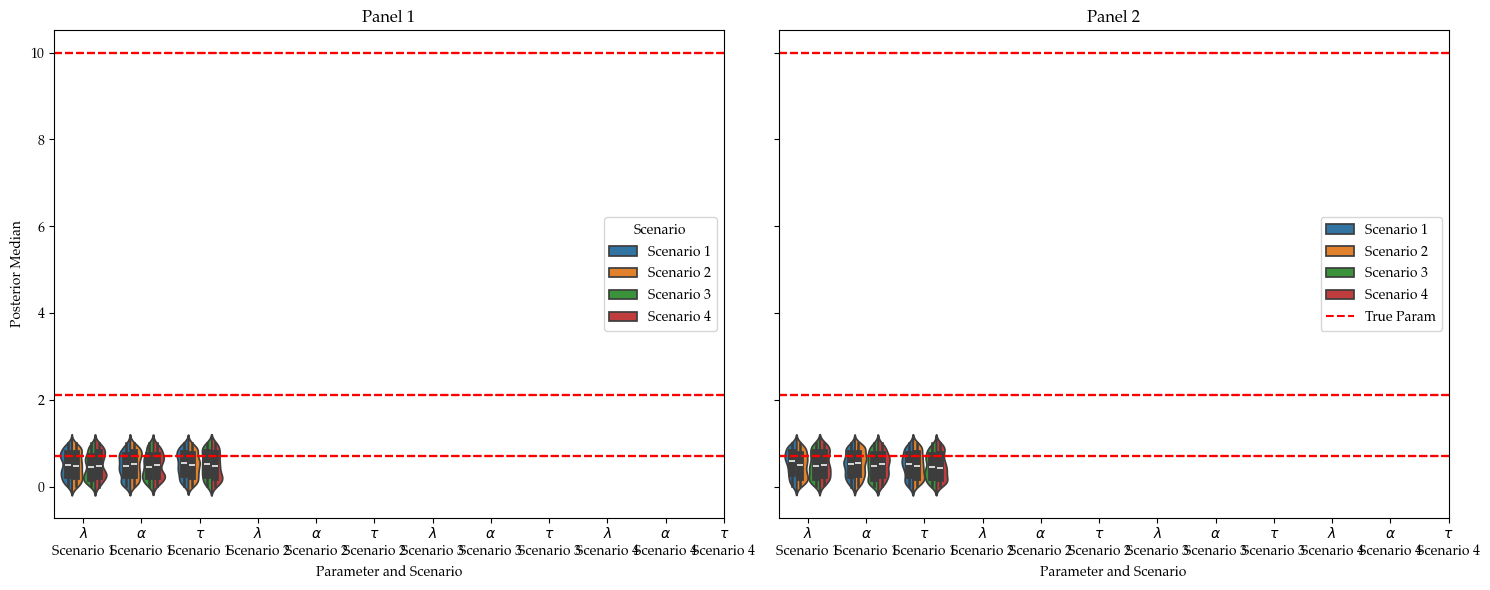

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data
pt_post_median = np.random.rand(2, 4, 200, 3)  # Replace with your actual data
true_params = np.array([[2.1, 0.7, 10], [2.1, 0.7, 10]])  # Replace with your actual true parameters

# Prepare data for plotting
data = []
param_names = [r'$\lambda$', r'$\alpha$', r'$\tau$']
panels = ['Panel 1', 'Panel 2']

for i in range(2):  # Loop over panels
    for j in range(3):  # Loop over parameters
        for k in range(4):  # Loop over scenarios
            for l in range(200):  # Loop over repetitions
                data.append([panels[i], f'{param_names[j]}', f'Scenario {k+1}', pt_post_median[i, k, l, j]])

data = np.array(data)
df = pd.DataFrame(data, columns=['Panel', 'Parameter', 'Scenario', 'Value'])
df['Value'] = df['Value'].astype(float)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i, panel in enumerate(panels):  # Loop over panels
    ax = axes[i]
    sns.violinplot(x='Parameter', y='Value', hue='Scenario', data=df[df['Panel'] == panel], ax=ax, split=True)
    for j in range(3):  # Loop over parameters
        for k in range(4):  # Loop over scenarios
            ax.axhline(y=true_params[i, j], color='r', linestyle='--', label='True Param' if j == 0 and k == 0 else "")
    ax.set_title(panel)
    ax.set_xlabel('Parameter and Scenario')
    if i == 0:
        ax.set_ylabel('Posterior Median')
    if i == 1:
        ax.legend()

# Customizing x-axis labels
for ax in axes:
    ax.set_xticks(np.arange(12))
    ax.set_xticklabels([f'{param}\nScenario {scenario}' for scenario in range(1, 5) for param in param_names])

plt.tight_layout()
plt.show()